3rd Test - Walker segmentation - Image 000 - 512x512


In [127]:
import sys
import os

# Add the project root folder path to sys.path
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from numpy import ndarray


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)



In [128]:
# Check input shape
print(hsv_img.shape) # Result: (1080, 1920, 3)

(1080, 1920, 3)


In [ ]:
# Inspect the actual color values ​​in the image for each pixel
# cv.imshow("Inspect Image", bgr_img)
cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

"""
Writing down values (Hue, Saturation, Value)
lower_bound = [142, 148, 187]
upper_bound = [145, 178, 225]
"""

In [129]:
# Preprocess
# Apply blur to reduce noise
hsv_img = cv.GaussianBlur(hsv_img, (5,5), 0)

In [ ]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

(1080, 1920)


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

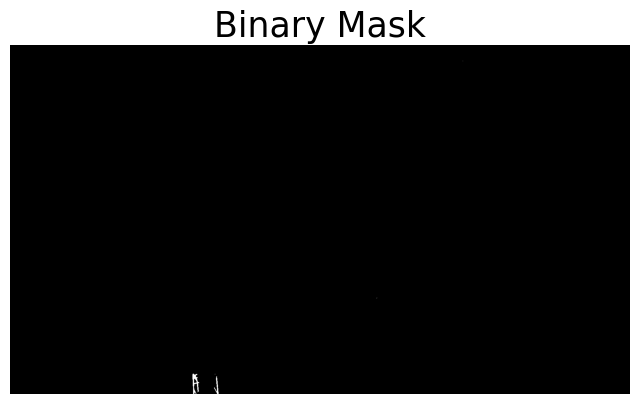

In [130]:
### Process ###
# First Step - Limits
# 1 - Define Walker color limits >> HSV (H:142, S:150, V:187) to (H:145, S:177, V:225)
# New values ​​considering preprocessing
lower_bound = np.array([142, 150, 187]) # Hue, Saturation, Value
upper_bound = np.array([145, 177, 225]) # Hue, Saturation, Value

# Second Step - Binary Mask
# 2.1 - Create mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)
mask = np.where(mask > 0, 255, 0).astype(np.uint8) # Binarização
print(mask.shape)

plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')


In [ ]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", mask)
cv.waitKey(0)
cv.destroyAllWindows()

"""
Values are 0 and 255.
"""

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

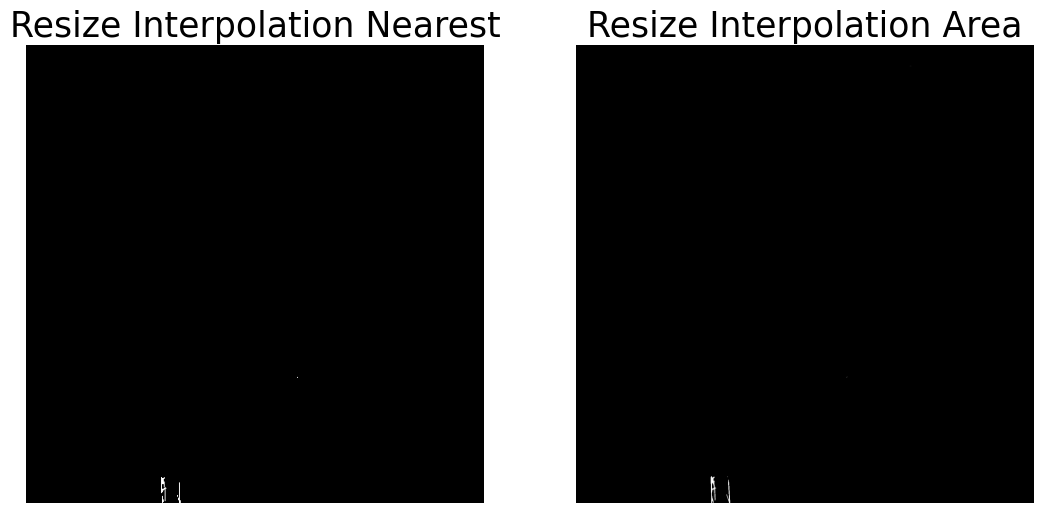

In [131]:
# Test: Resize mask and image
mask1 = cv.resize(mask, (512, 512), interpolation=cv.INTER_NEAREST)
mask2 = cv.resize(mask, (512, 512), interpolation=cv.INTER_AREA)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(mask1, cmap='gray')
plt.title("Resize Interpolation Nearest",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask2, cmap='gray')
plt.title("Resize Interpolation Area",fontdict={'fontsize': 25})
plt.axis('off')

In [132]:
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Image", mask)

# cv.imshow("Inspect Image", mask1) # Mask 1 (512x512 - Nearest): Values are 0 and 255
cv.imshow("Inspect Image", mask2)   # Mask 2 (512x512 - Area): Values between 0 and 255

cv.waitKey(0)
cv.destroyAllWindows()

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

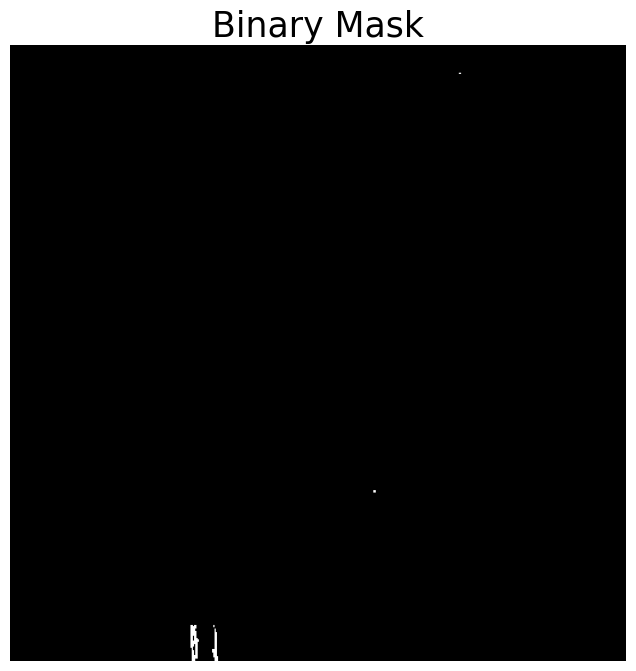

In [133]:
# 2.3 - Binarize mask
mask = np.where(mask2 > 0, 255, 0).astype(np.uint8)

# 2.4 - Visualize binary mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

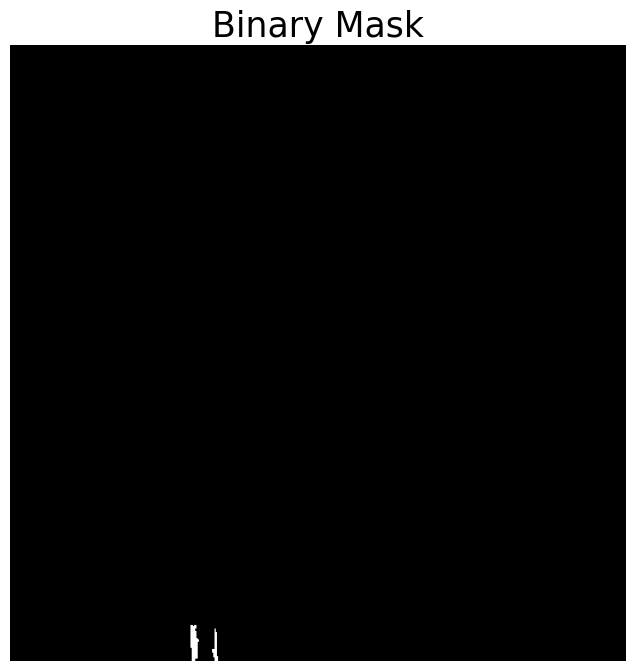

In [98]:
# Third Step - Remove Noise
# 3.1 - Find Contours
contours, hierarchy = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 5 # manual fine tuning

# 3.2 - Filter
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        cv.drawContours(filtered_mask, [contour], -1, (255), -1)

# 3.3 - Reassign mask with the filtered mask
mask = filtered_mask

# 3.4 - Visualize updated mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')


'\nBad results with resize\n'

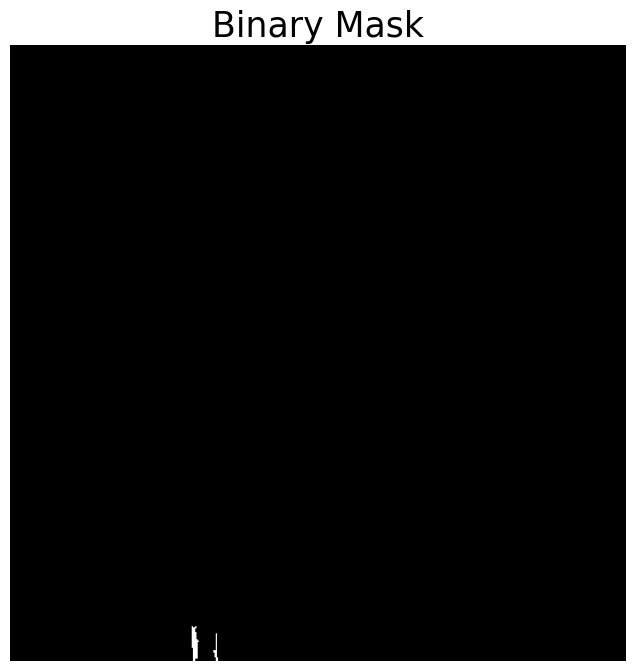

In [102]:
# Morphologic Operation
# 3. Post-processing
kernel = np.ones((2,2), np.uint8)
# mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)  # Remove small noise
# mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel) # Close small holes

# dilated_mask = cv.dilate(mask, kernel, iterations=2)
eroded_mask = cv.erode(mask, kernel, iterations=1)

plt.figure(figsize=[8,8])
# plt.imshow(dilated_mask, cmap='gray')
plt.imshow(eroded_mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

"""
Bad results with resize
"""

In [103]:
# 3.5 - Check Mask values
cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

mask.shape

(512, 512)

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

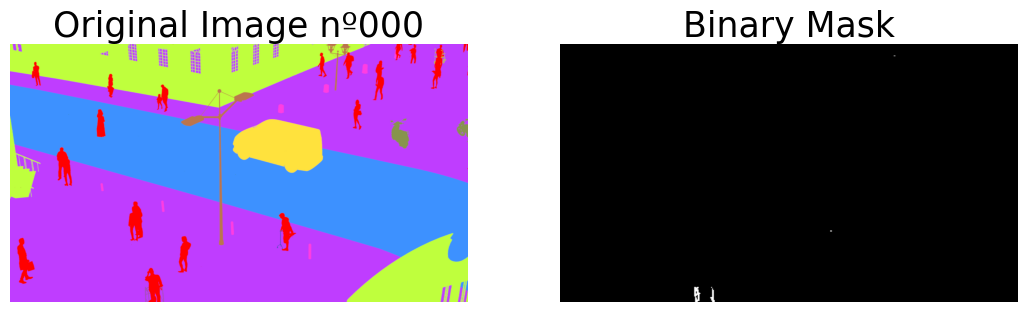

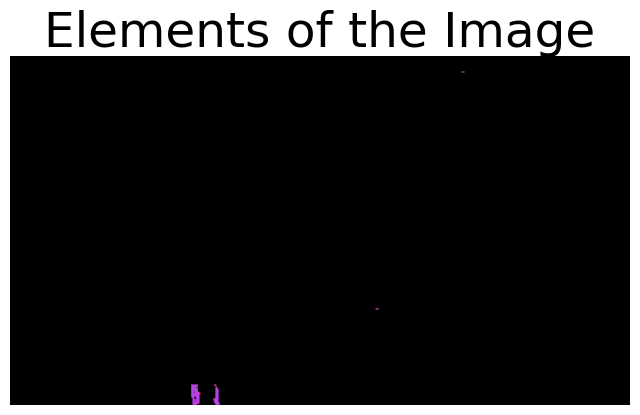

In [136]:
# Visualize Segmentation
bgr_img = cv.resize(bgr_img, (1920, 1080), interpolation=cv.INTER_NEAREST)
mask = cv.resize(mask, (1920, 1080), interpolation=cv.INTER_NEAREST)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[8,8])
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

4th Test - Walker Segmentation - Image 368 - 512x512

In [118]:
import sys
import os

# Add the project root folder path to sys.path
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)


In [ ]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

In [119]:
# Preprocess
# Apply blur to reduce noise
hsv_img = cv.GaussianBlur(hsv_img, (5,5), 0)

In [ ]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

"""
Writing down values (Hue, Saturation, Value)
lower_bound = [142, 148, 187]
upper_bound = [145, 178, 225]

No changes for now.
"""

(1080, 1920)


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

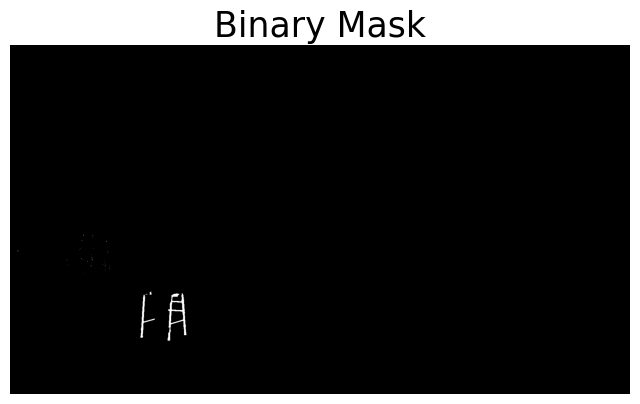

In [125]:
### Process ###
# First Step - Limits
# 1 - Define Walker color limits >> HSV (H:142, S:150, V:187) to (H:145, S:177, V:225)
# New values ​​considering preprocessing
lower_bound = np.array([142, 150, 187]) # Hue, Saturation, Value
upper_bound = np.array([145, 177, 225]) # Hue, Saturation, Value

# Second Step - Binary Mask
# 2.1 - Create mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)
mask = np.where(mask > 0, 255, 0).astype(np.uint8) # Binarização
print(mask.shape)

plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

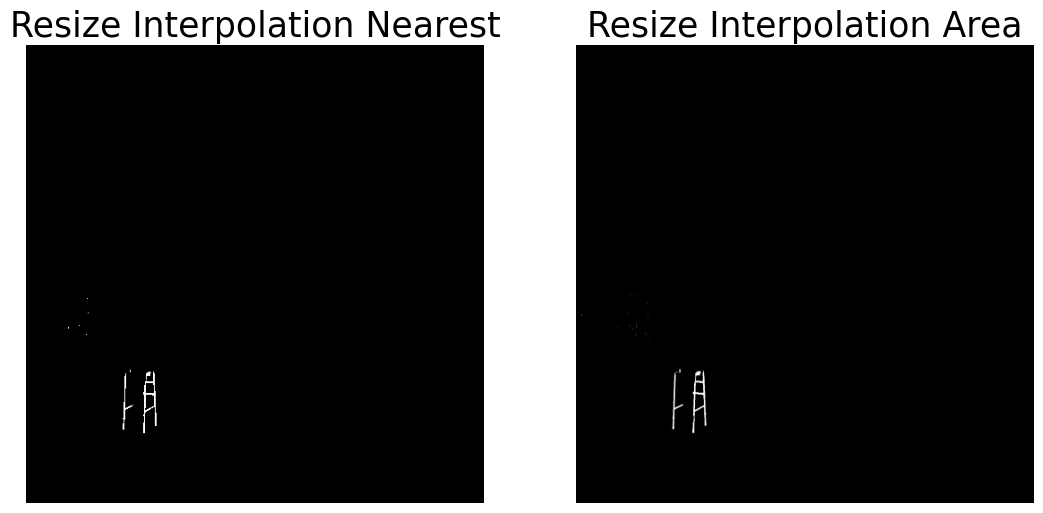

In [126]:
# Test: Resize mask and image
mask1 = cv.resize(mask, (512, 512), interpolation=cv.INTER_NEAREST)
mask2 = cv.resize(mask, (512, 512), interpolation=cv.INTER_AREA)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(mask1, cmap='gray')
plt.title("Resize Interpolation Nearest",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask2, cmap='gray')
plt.title("Resize Interpolation Area",fontdict={'fontsize': 25})
plt.axis('off')

In [ ]:
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Image", mask)

# cv.imshow("Inspect Image", mask1) # Mask 1 (512x512 - Nearest): Values are 0 and 255
cv.imshow("Inspect Image", mask2)   # Mask 2 (512x512 - Area): Values between 0 and 255

cv.waitKey(0)
cv.destroyAllWindows()
"""
Maybe change the Binarize Method with threshold over 127 instead 0
"""

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

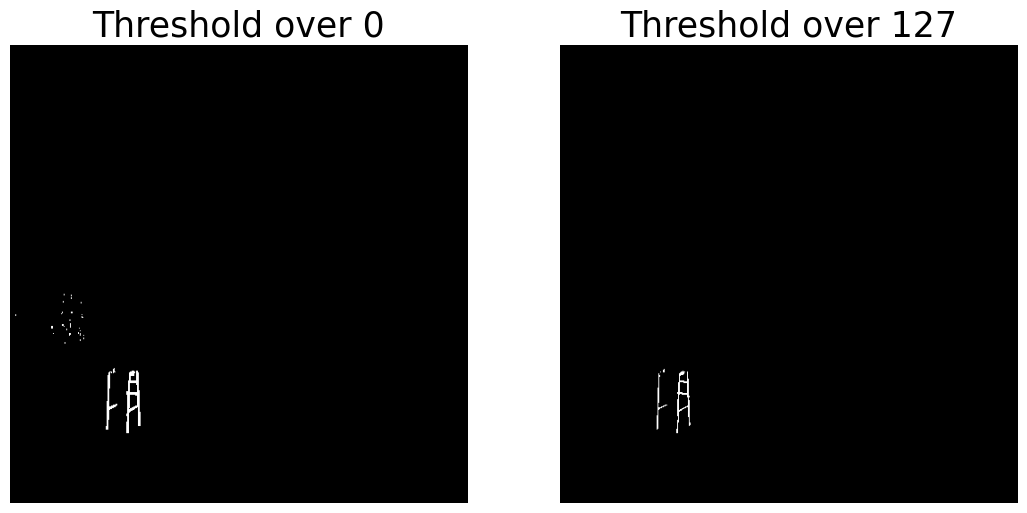

In [122]:
# 2.2 - Binarize
th0 = np.where(mask2 > 0, 255, 0).astype(np.uint8)
th127 = np.where(mask2 > 127, 255, 0).astype(np.uint8)

# # 2.3 - Visualize binary mask
# plt.figure(figsize=[8,8])
# plt.imshow(mask, cmap='gray')
# plt.title("Binary Mask",fontdict={'fontsize': 25})
# plt.axis('off')

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(th0, cmap='gray')
plt.title("Threshold over 0",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(th127, cmap='gray')
plt.title("Threshold over 127",fontdict={'fontsize': 25})
plt.axis('off')

In [ ]:
# cv.imshow("Inspect Image", th0)
cv.imshow("Inspect Image", th127) # Remove noise, however needs adjustment

cv.waitKey(0)
cv.destroyAllWindows()

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

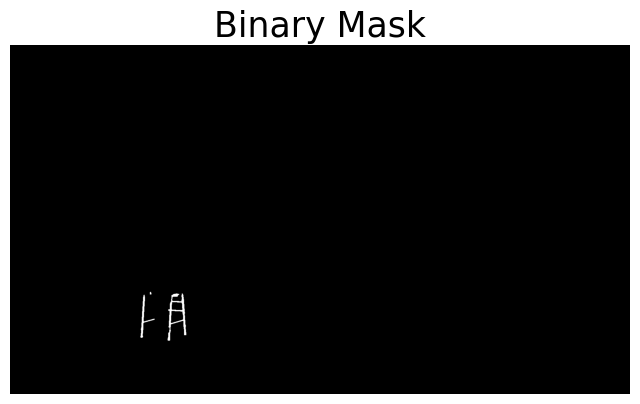

In [ ]:
# Morphologic Operation
# 3. Post-processing
kernel = np.ones((3,3), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)  # Remove small noise
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel) # Close small holes

# plt.figure(figsize=[8,8])
# plt.imshow(mask, cmap='gray')
# plt.title("Binary Mask",fontdict={'fontsize': 25})
# plt.axis('off')

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(th0, cmap='gray')
plt.title("Test 1",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(th127, cmap='gray')
plt.title("Teste 2",fontdict={'fontsize': 25})
plt.axis('off')

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

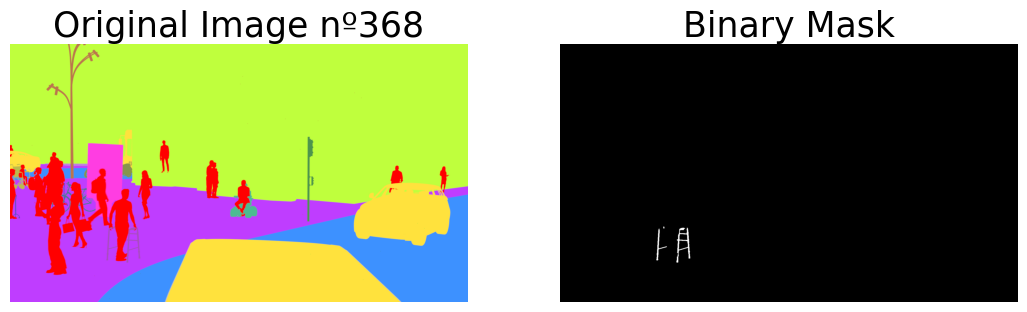

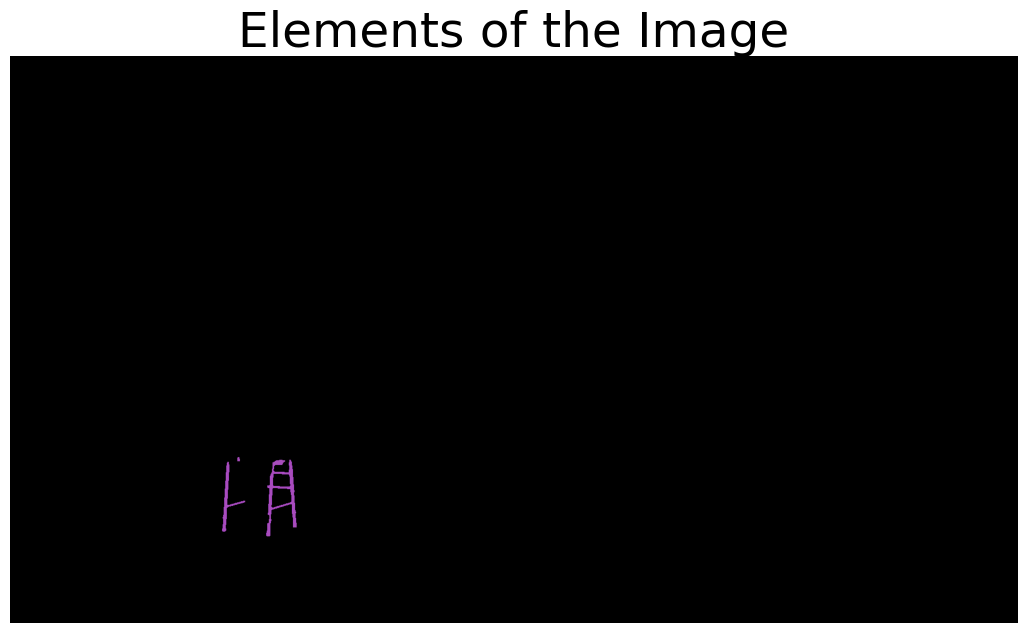

In [109]:
# Visualize Segmentation
# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[13,13])
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')